[![Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/giordamaug/decouple_emb_lgbm/blob/main/notebook.ipynb)

## Libraries

In [1]:
import torch
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter(action='ignore')
import numpy as np
import os
import random
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"       # to force BERT determinsm

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # per multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)

## Load dataset

In [2]:
import sys
sys.path.append('.')
from scripts.utils import Settings

datafile =  "data/ina_asplenic_1789.json" # "dataset_5flw_1inf.json" "mimic_patients_events.json"
args = Settings(datafile = datafile, 
                no_selection=False,
                pathology_field = 'base_pathology_area',
                static_vars= ["gender", "age_group", "base_pathology_area"],
                target_var = 'is_dead?',
                pathologies={'Asplenic Syndromes' : 'AS', 
                            'Autoimmune Hematological Diseases' : 'AIHD', 
                            'Congenital Hemolytic Anemias' : 'CHA', 
                            'Immunodeficiencies' : 'IM', 
                            'NTDT - (Non Transfusion Dependent Thalassemia - Intermediate Thalassemia)' : 'NTDT', 
                            'Non-Hemato-Oncological Causes' : 'NHOC', 
                            'Oncological Diseases' : 'OD', 
                            'SCD - (Sickle Cell Disease, Anemia/Sickle Cell or Sickle Cell Disease)' : 'SCD', 
                            'TDT - (Transfusion Dependent Thalassemia - Thalassemia Major)' : 'TDT'},
                selected_spleen_flags = ['YES'],
                methods=['LSTM', 'GRU', 'GRU-D', 'BEHRT', 'Dipole', 'DOME', 'BINARY'],
                evfields = ['event'],
                remove_events = ['followup', 'platelet', 'bmi_change'],
                enable_plot=True, 
                n_splits=5, 
                num_epochs=10, 
                batch_size = 16, 
                embedding_size=128,
                hidden_size=300)

Loaded 1492 records from data/ina_asplenic_1789.json


## Plot patients distribution

Index(['CHA', 'TDT', 'NTDT', 'AIHD', 'SCD', 'NHOC', 'OD', 'IM', 'AS'], dtype='object', name='base_pathology_area')


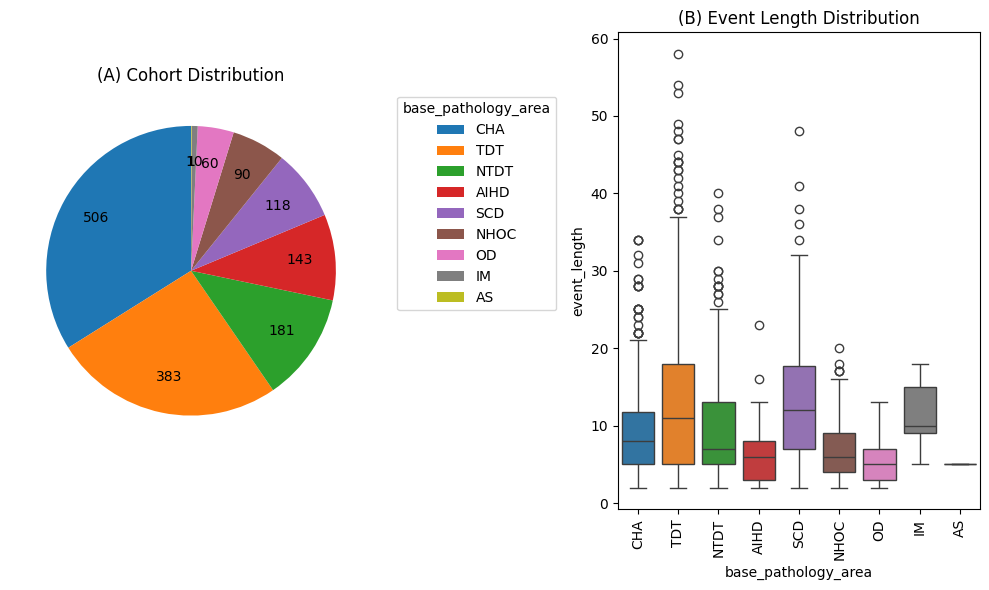

In [5]:
from scripts.utils import plot_group_distribution_with_event_boxplot
plot_group_distribution_with_event_boxplot(args.dataset, groupby=args.pathology_field, label_desc=args.pathologies)

## Get clinical trajectories

### count event by type and cardinality

In [27]:
from scripts.utils import count_events_by_type
events_field, date_field, type_field = 'events', 'date', 'type'
event_sequences = { id: [(" ".join([event[field] for field in args.evfields]), event[date_field], event[type_field]) for event in events] for (id,events) in args.dataset[[events_field]].to_dict()[events_field].items()} 
cnt_df = count_events_by_type(event_sequences)
cnt_df

,cardinality,n. instances,set
type,,,
therapy,40,5041,"{antiplatelet, hormonal, antifungal, transfusi..."
splenectomy,1,1492,{splenectomy}
vaccination,9,6576,"{vaccine meningococcus C, vaccine PCV13, vacci..."
surgical operation,17,76,"{nevus excision, hematopoietic transplant, nep..."
infection,37,561,"{systemic parasitic infection, zoonotic bacter..."
bmi_change,2,4,"{overweight, underweight}"
platelet,3,670,"{plt_low, plt_medium, plt_high}"
comorbidity,15,844,"{ophthalmological and hearing diseases, dermat..."
trombosys,4,191,"{arterial/venous thrombosis, venous thrombosis..."


### Remove events by types

In [28]:
from scripts.utils import group_events_by_visit
# get sequence of event names
event_sequences = { id: [(" ".join([event[field] for field in args.evfields]), event[date_field]) for event in events if event[type_field] not in args.remove_events] for (id,events) in args.dataset[[events_field]].to_dict()[events_field].items()} 
visit_sequences = group_events_by_visit(event_sequences)
print(f"n.{len(event_sequences)} Patients")

n.1492 Patients


## Get static variables

In [29]:
if len(args.static_vars) > 0:
    mapper = {'pediatric': 0, 'adolescent' : 1, 'adult': 2, 'ND' : -1, 'young': 0, 'mature' : 1, 'elder': 2, 'geriatric': 3}
    X_static = args.dataset.loc[args.selected_patient_ids][args.static_vars].copy()
    X_static.replace(mapper, inplace=True)
    cnames = list(X_static.select_dtypes(include=['object']).columns)
    for col in cnames:
        X_static[col], _ = pd.factorize(X_static[col])
else:
    X_static = pd.DataFrame(index=args.selected_patient_ids)
X_static

,gender,age_group,base_pathology_area
id,,,
1,0,0,0
2,1,0,1
3,0,0,1
4,1,0,1
5,0,0,2
...,...,...,...
1948,1,0,1
1949,1,0,1
1950,1,2,1


## Get targets

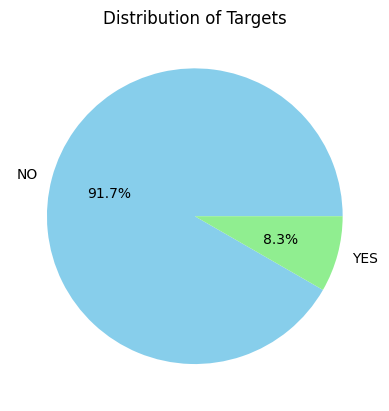

In [30]:
import matplotlib.pyplot as plt
target_df = args.dataset[args.target_var].copy()
counts = target_df.value_counts()
counts.plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'lightgreen'])
plt.title('Distribution of Targets')
plt.ylabel('')
target_df.replace({"YES": 1, "NO": 0}, inplace=True)
plt.show()

In [31]:
if False:
    from scripts.embedding import FlexLSTMembedder, BEHRTembedder, COUNTEREmbedder, TimeAwareLSTMEmbedder, DipoleEmbedder 
    from scripts.embedding import StaticEmbedder, RETAINembedder, DOMEEmbedder, BINARYEmbedder, GRUEmbedder, GRUEDembedder
    from scripts.classifiers import FlexLSTMclassifier, DipoleClassifier, BEHRTclassifier, GRUclassifier, GRUDclassifier
    # === Vocabolario per LSTM ===
    vocab = set()
    for patient_events in event_sequences.values():
        for event,date in patient_events:
            vocab.update([event] if isinstance(event, str) else event)
    word_to_idx = {word: idx for idx, word in enumerate(sorted(vocab))}  # for LSTM, RETAIN, etc
    # === Vocabolario per BEHRT ===
    code2id = {"[PAD]": 0, "[CLS]": 1, "[SEP]": 2}
    idx = 3
    for pid, visits in visit_sequences.items():
        for events, date in visits:
            for event in events:
                if event not in code2id:
                    code2id[event] = idx
                    idx += 1

    labels = target_df.to_dict()
    embedder_configs =  { 
            "LSTM" : 
            {   "func": FlexLSTMembedder,
                "clf": FlexLSTMclassifier,
                "kwargs": {
                    "name": "LSTM",
                    "sequences": event_sequences,
                    "labels": labels,
                    "word_to_idx": word_to_idx,
                    "num_epochs": args.num_epochs,
                    "batch_size": args.batch_size,
                    "embed_size": args.embedding_dim,
                    "hidden_size": args.hidden_dim,
                    "enable_plot": args.enable_plot,
                    "pooling": True,
                    "use_padding": False,
                    "bidirectional": False,
                    "use_attention": False
                }
            },
            "LSTMnopool" : 
            {   "func": FlexLSTMembedder,
                "clf": FlexLSTMclassifier,
                "kwargs": {
                    "name": "LSTMnopool",
                    "sequences": event_sequences,
                    "labels": labels,
                    "word_to_idx": word_to_idx,
                    "num_epochs": args.num_epochs,
                    "batch_size": args.batch_size,
                    "embed_size": args.embedding_dim,
                    "hidden_size": args.hidden_dim,
                    "enable_plot": args.enable_plot,
                    "pooling": False,
                    "use_padding": False,
                    "bidirectional": False,
                    "use_attention": False
                }
            },
            "AttLSTM" : 
            {   "func": FlexLSTMembedder,
                "clf": FlexLSTMclassifier,
                "kwargs": {
                    "name": "AttLSTM",
                    "sequences": event_sequences,
                    "labels": labels,
                    "word_to_idx": word_to_idx,
                    "num_epochs": args.num_epochs,
                    "batch_size": args.batch_size,
                    "embed_size": args.embedding_dim,
                    "hidden_size": args.hidden_dim,
                    "enable_plot": args.enable_plot,
                    "pooling": True,
                    "use_padding": False,
                    "bidirectional": False,
                    "use_attention": True
                }
            },
            "PadLSTM" : 
            {   "func": FlexLSTMembedder,
                "clf": FlexLSTMclassifier,
                "kwargs": {
                    "name": "PadLSTM",
                    "sequences": event_sequences,
                    "labels": labels,
                    "word_to_idx": word_to_idx,
                    "num_epochs": args.num_epochs,
                    "batch_size": args.batch_size,
                    "embed_size": args.embedding_dim,
                    "hidden_size": args.hidden_dim,
                    "enable_plot": args.enable_plot,
                    "pooling": True,
                    "use_padding": True,
                    "bidirectional": False,
                    "use_attention": False
                }
            },
            "PadAttLSTM" : 
            {   "func": FlexLSTMembedder,
                "clf": FlexLSTMclassifier,
                "kwargs": {
                    "name": "PadAttLSTM",
                    "sequences": event_sequences,
                    "labels": labels,
                    "word_to_idx": word_to_idx,
                    "num_epochs": args.num_epochs,
                    "batch_size": args.batch_size,
                    "embed_size": args.embedding_dim,
                    "hidden_size": args.hidden_dim,
                    "enable_plot": args.enable_plot,
                    "pooling": True,
                    "use_padding": True,
                    "bidirectional": False,
                    "use_attention": True
                }
            },
            "BiLSTM" : 
            {   "func": FlexLSTMembedder,
                "clf": FlexLSTMclassifier,
                "kwargs": {
                    "name": "BiLSTM",
                    "sequences": event_sequences,
                    "labels": labels,
                    "word_to_idx": word_to_idx,
                    "num_epochs": args.num_epochs,
                    "batch_size": args.batch_size,
                    "embed_size": args.embedding_dim,
                    "hidden_size": args.hidden_dim,
                    "enable_plot": args.enable_plot,
                    "pooling": True,
                    "use_padding": False,
                    "bidirectional": True,
                    "use_attention": False
                }
            },
            "BiPadLSTM" : 
            {   "func": FlexLSTMembedder,
                "clf": FlexLSTMclassifier,
                "kwargs": {
                    "name": "BiPadLSTM",
                    "sequences": event_sequences,
                    "labels": labels,
                    "word_to_idx": word_to_idx,
                    "num_epochs": args.num_epochs,
                    "batch_size": args.batch_size,
                    "embed_size": args.embedding_dim,
                    "hidden_size": args.hidden_dim,
                    "enable_plot": args.enable_plot,
                    "pooling": True,
                    "use_padding": True,
                    "bidirectional": True,
                    "use_attention": False
                }
            },
            "FlexLSTM" : 
            {   "func": FlexLSTMembedder,
                "clf": FlexLSTMclassifier,
                "kwargs": {
                    "name": "FlexLSTM",
                    "sequences": event_sequences,
                    "labels": labels,
                    "word_to_idx": word_to_idx,
                    "num_epochs": args.num_epochs,
                    "batch_size": args.batch_size,
                    "embed_size": args.embedding_dim,
                    "hidden_size": args.hidden_dim,
                    "enable_plot": args.enable_plot,
                    "pooling": True,
                    "use_padding": False,
                    "bidirectional": True,
                    "use_attention": False
                }
            },
            "BiLSTMnopool" : 
            {   "func": FlexLSTMembedder,
                "clf": FlexLSTMclassifier,
                "kwargs": {
                    "name": "BiLSTMnopool",
                    "sequences": event_sequences,
                    "labels": labels,
                    "word_to_idx": word_to_idx,
                    "num_epochs": args.num_epochs,
                    "batch_size": args.batch_size,
                    "embed_size": args.embedding_dim,
                    "hidden_size": args.hidden_dim,
                    "enable_plot": args.enable_plot,
                    "pooling": False,
                    "use_padding": False,
                    "bidirectional": True,
                    "use_attention": False
                }
            },
            "BiAttLSTMnopool" : 
            {   "func": FlexLSTMembedder,
                "clf": FlexLSTMclassifier,
                "kwargs": {
                    "name": "BiAttLSTMnopool",
                    "sequences": event_sequences,
                    "labels": labels,
                    "word_to_idx": word_to_idx,
                    "num_epochs": args.num_epochs,
                    "batch_size": args.batch_size,
                    "embed_size": args.embedding_dim,
                    "hidden_size": args.hidden_dim,
                    "enable_plot": args.enable_plot,
                    "pooling": False,
                    "use_padding": False,
                    "bidirectional": True,
                    "use_attention": True
                }
            },
            "BiAttLSTM" : 
            {   "func": FlexLSTMembedder,
                "clf": FlexLSTMclassifier,
                "kwargs": {
                    "name": "BiAttLSTM",
                    "sequences": event_sequences,
                    "labels": labels,
                    "word_to_idx": word_to_idx,
                    "num_epochs": args.num_epochs,
                    "batch_size": args.batch_size,
                    "embed_size": args.embedding_dim,
                    "hidden_size": args.hidden_dim,
                    "enable_plot": args.enable_plot,
                    "pooling": True,
                    "use_padding": False,
                    "bidirectional": True,
                    "use_attention": True
                }
            },
            "BiPadAttLSTM" : 
            {   "func": FlexLSTMembedder,
                "clf": FlexLSTMclassifier,
                "kwargs": {
                    "name": "BiPadAttLSTM",
                    "sequences": event_sequences,
                    "labels": labels,
                    "word_to_idx": word_to_idx,
                    "num_epochs": args.num_epochs,
                    "batch_size": args.batch_size,
                    "embed_size": args.embedding_dim,
                    "hidden_size": args.hidden_dim,
                    "enable_plot": args.enable_plot,
                    "pooling": True,
                    "use_padding": True,
                    "bidirectional": True,
                    "use_attention": True
                }
            },
            "RETAIN" : 
            {   "func": RETAINembedder,
                "kwargs": {
                    "sequences": visit_sequences,
                    "labels": labels,
                    "word_to_idx": code2id,
                    "num_epochs": args.num_epochs,
                    "batch_size": args.batch_size,
                    "embed_size": args.embedding_dim,
                    "hidden_size": args.hidden_dim,
                    "enable_plot": args.enable_plot
                }
            },
            "BEHRT" : 
            {   "func": BEHRTembedder,
                "clf": BEHRTclassifier,
                "kwargs": {
                    "sequences": visit_sequences,
                    "labels": labels,
                    "word_to_idx": code2id,
                    "num_epochs": args.num_epochs,
                    "batch_size": args.batch_size,
                    "embed_size": args.embedding_dim,
                    "hidden_size": args.hidden_dim,
                    "enable_plot": args.enable_plot
                }
            },
            "Dipole" : 
            {   "func": DipoleEmbedder,
                "clf": DipoleClassifier,
                "kwargs": {
                    "sequences": event_sequences,
                    "labels": labels,
                    "word_to_idx": code2id,
                    "num_epochs": args.num_epochs,
                    "batch_size": args.batch_size,
                    "embed_size": args.embedding_dim,
                    "hidden_size": args.hidden_dim,
                    "enable_plot": args.enable_plot
                }
            },
            "tLSTM" : 
            {   "func": TimeAwareLSTMEmbedder,
                "kwargs": {
                    "sequences": event_sequences,
                    "labels": labels,
                    "word_to_idx": word_to_idx,
                    "num_epochs": args.num_epochs,
                    "batch_size": args.batch_size,
                    "embed_size": args.embedding_dim,
                    "hidden_size": args.hidden_dim,
                    "enable_plot": args.enable_plot
                }
            },
            "GRU-D" : 
            {   "func": GRUEDembedder,
                "clf": GRUDclassifier,
                "kwargs": {
                    "sequences": visit_sequences,
                    "labels": labels,
                    "word_to_idx": code2id,
                    "num_epochs": args.num_epochs,
                    "batch_size": args.batch_size,
                    "embed_size": args.embedding_dim,
                    "hidden_size": args.hidden_dim,
                    "enable_plot": args.enable_plot
                }
            },
            "GRU" : 
            {   "func": GRUEmbedder,
                "clf": GRUclassifier,
                "kwargs": {
                    "sequences": event_sequences,
                    "labels": labels,
                    "word_to_idx": word_to_idx,
                    "num_epochs": args.num_epochs,
                    "batch_size": args.batch_size,
                    "embed_size": args.embedding_dim,
                    "hidden_size": args.hidden_dim,
                    "enable_plot": args.enable_plot
                }
            },
            "STATIC" : 
            {   "func": StaticEmbedder,
                "kwargs": {
                    "df": X_static,
                    "include_attributes": args.static_vars,
                    "enable_plot": args.enable_plot
                }
            },
            "DOME" :
            {
                "func": DOMEEmbedder,
                "kwargs": {
                    "sequences": event_sequences,
                    "targets": [args.target_var],
                    "df": args.dataset,
                    "enable_plot": args.enable_plot
                }
            },
            "BINARY": 
            {
                "func": BINARYEmbedder,
                "kwargs": {
                    "sequences": event_sequences,
                    "vocab": vocab,
                    "targets": [args.target_var],
                    "enable_plot": args.enable_plot
                }
            },
            "COUNTER": 
            {
                "func": COUNTEREmbedder,
                "kwargs": {
                    "sequences": event_sequences,
                    "vocab": vocab | set('dead'),
                    "targets": [args.target_var],
                    "enable_plot": args.enable_plot
                }
            }
        }


In [32]:
from scripts.configure import configure
embedder_configs = configure(event_sequences, visit_sequences, target_df.to_dict(), X_static, args)

## Validate

In [33]:
#Create empty dataframe for results collections
cols = ["AUC mean","AUC std","F1 mean","F1 std","Prec mean","Prec std","Recall mean","Recall std","MCC mean","MCC std","Acc mean","Acc std","CM"]
dtypes = {"AUC mean": "float64", "AUC std": "float64","F1 mean": "float64","F1 std": "float64","Prec mean": "float64","Prec std": "float64","Recall mean": "float64","Recall std": "float64","MCC mean": "float64","MCC std": "float64","Acc mean": "float64","Acc std": "float64", "CM": "string"}

# Pre-allocate empty DataFrame with correct dtypes
results_df = pd.DataFrame(
    {c: pd.Series(dtype=dt) for c, dt in dtypes.items()},
    columns=cols
)

In [34]:
from scripts.cv_folding import lgbm_cv
set_seed(args.random_state)
results_tmp, model, train_df, test_df, y_train, y_test= lgbm_cv(embedder_configs, target_df, args.selected_patient_ids,
                                                                methods=['STATIC', 'BiPadLSTM'])
results_df = pd.concat([results_df, results_tmp],axis=0)
results_df

,AUC mean,AUC std,F1 mean,F1 std,Prec mean,Prec std,Recall mean,Recall std,MCC mean,MCC std,Acc mean,Acc std,CM
STATIC+BiPadLSTM,0.870825,0.027947,0.556292,0.049161,0.511179,0.055825,0.613333,0.051294,0.515151,0.05439,0.918244,0.012716,"[[1294, 74], [48, 76]]"
